导出

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

CFL number: 0.0318 (should be <=1 for stability)


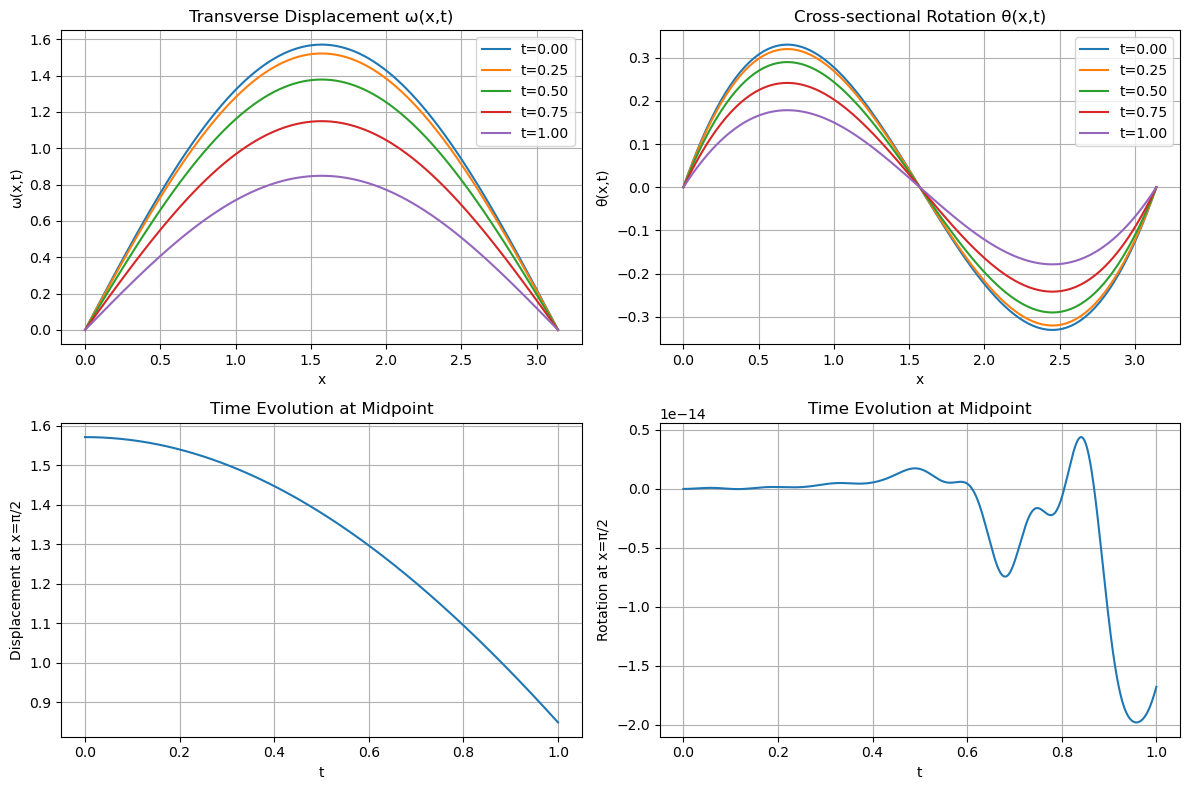

✅ Readable CSV files exported to: results_grok_csv


In [4]:
# =============================
# Problem parameters
# =============================
L = np.pi
T = 1.0
Nx = 101
Nt = 1001

dx = L / (Nx - 1)
dt = T / (Nt - 1)
x = np.linspace(0, L, Nx)
t_values = np.linspace(0, T, Nt)

# Stability check
cfl = dt / dx
print(f"CFL number: {cfl:.4f} (should be <=1 for stability)")

# =============================
# Initial conditions
# =============================
omega = np.zeros((Nt, Nx))
theta = np.zeros((Nt, Nx))

omega[0, :] = (np.pi/2.0) * np.sin(x)
theta[0, :] = (np.pi/2.0) * np.cos(x) + (x - np.pi / 2)

# =============================
# External force
# =============================
def g(x, t):
    return np.cos(t) - (np.pi/2.0) * np.sin(x) * np.cos(t)

d2_factor = 1.0 / (dx ** 2)
d1_factor = 1.0 / (2 * dx)


def rhs_theta(omega_n, theta_n):
    theta_xx = np.zeros(Nx)
    omega_x = np.zeros(Nx)
    
    for i in range(1, Nx-1):
        theta_xx[i] = d2_factor * (theta_n[i+1] - 2*theta_n[i] + theta_n[i-1])
        omega_x[i] = d1_factor * (omega_n[i+1] - omega_n[i-1])
    
    rhs = np.zeros(Nx)
    for i in range(1, Nx-1):
        rhs[i] = theta_xx[i] - (theta_n[i] - omega_x[i])
    
    return rhs


def rhs_omega(omega_n, theta_n, t):
    theta_x = np.zeros(Nx)
    omega_xx = np.zeros(Nx)
    
    for i in range(1, Nx-1):
        theta_x[i] = d1_factor * (theta_n[i+1] - theta_n[i-1])
        omega_xx[i] = d2_factor * (omega_n[i+1] - 2*omega_n[i] + omega_n[i-1])
    
    rhs = np.zeros(Nx)
    g_val = g(x, t)
    for i in range(1, Nx-1):
        rhs[i] = g_val[i] - (theta_x[i] - omega_xx[i])  # g - (θ_x - ω_xx)
    
    return rhs


# =============================
# First time step
# =============================
rhs_theta_0 = rhs_theta(omega[0, :], theta[0, :])
rhs_omega_0 = rhs_omega(omega[0, :], theta[0, :], t_values[0])

dt2 = dt ** 2
half_dt2 = 0.5 * dt2

omega[1, 1:Nx-1] = omega[0, 1:Nx-1] + half_dt2 * rhs_omega_0[1:Nx-1]
theta[1, 1:Nx-1] = theta[0, 1:Nx-1] + half_dt2 * rhs_theta_0[1:Nx-1]

omega[1, 0] = omega[1, -1] = 0.0
theta[1, 0] = theta[1, -1] = 0.0


# =============================
# Time marching
# =============================
for n in range(1, Nt-1):
    rhs_theta_n = rhs_theta(omega[n, :], theta[n, :])
    rhs_omega_n = rhs_omega(omega[n, :], theta[n, :], t_values[n])

    omega[n+1, 1:Nx-1] = 2 * omega[n, 1:Nx-1] - omega[n-1, 1:Nx-1] + dt2 * rhs_omega_n[1:Nx-1]
    theta[n+1, 1:Nx-1] = 2 * theta[n, 1:Nx-1] - theta[n-1, 1:Nx-1] + dt2 * rhs_theta_n[1:Nx-1]

    omega[n+1, 0] = omega[n+1, -1] = 0.0
    theta[n+1, 0] = theta[n+1, -1] = 0.0


# =============================
# Plot results (原代码不变)
# =============================
plot_times = [0, 0.25, 0.5, 0.75, 1.0]
time_indices = [np.argmin(np.abs(t_values - pt)) for pt in plot_times]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
for idx in time_indices:
    plt.plot(x, omega[idx, :], label=f't={t_values[idx]:.2f}')
plt.xlabel('x')
plt.ylabel('ω(x,t)')
plt.title('Transverse Displacement ω(x,t)')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
for idx in time_indices:
    plt.plot(x, theta[idx, :], label=f't={t_values[idx]:.2f}')
plt.xlabel('x')
plt.ylabel('θ(x,t)')
plt.title('Cross-sectional Rotation θ(x,t)')
plt.legend()
plt.grid(True)

x_mid = np.pi / 2
mid_idx = np.argmin(np.abs(x - x_mid))

plt.subplot(2, 2, 3)
plt.plot(t_values, omega[:, mid_idx], label='ω(π/2, t)')
plt.xlabel('t')
plt.ylabel('Displacement at x=π/2')
plt.title('Time Evolution at Midpoint')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(t_values, theta[:, mid_idx], label='θ(π/2, t)')
plt.xlabel('t')
plt.ylabel('Rotation at x=π/2')
plt.title('Time Evolution at Midpoint')
plt.grid(True)

plt.tight_layout()
plt.show()


# =========================================================
# ✅ ✅ ✅ 与前一段代码“完全一致格式”的 CSV 导出功能
# =========================================================
def export_results_csv_readable(x, t, omega, theta, folder_name="results_csv"):
    os.makedirs(folder_name, exist_ok=True)

    # 注意：这里必须转置 omega.T 和 theta.T
    omega_T = omega.T   # 形状: (Nx, Nt)
    theta_T = theta.T

    df_omega = pd.DataFrame(
        omega_T,
        index=np.round(x, 6),
        columns=np.round(t, 6)
    )
    df_omega.index.name = "x"
    df_omega.columns.name = "t"
    df_omega.to_csv(os.path.join(folder_name, "omega_full.csv"))

    df_theta = pd.DataFrame(
        theta_T,
        index=np.round(x, 6),
        columns=np.round(t, 6)
    )
    df_theta.index.name = "x"
    df_theta.columns.name = "t"
    df_theta.to_csv(os.path.join(folder_name, "theta_full.csv"))

    pd.DataFrame({
        "x": x,
        "omega_final": omega[-1, :]
    }).to_csv(os.path.join(folder_name, "omega_final.csv"), index=False)

    pd.DataFrame({
        "x": x,
        "theta_final": theta[-1, :]
    }).to_csv(os.path.join(folder_name, "theta_final.csv"), index=False)

    print("✅ Readable CSV files exported to:", folder_name)


# =============================
# ✅ 执行导出（只新增这一句）
# =============================
export_results_csv_readable(x, t_values, omega, theta, folder_name="results_grok_csv")
